In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import cell2location
from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs

In [2]:
results_folder = './cell2location_results/'
# create paths and names to results folders for reference regression and cell2location models
ref_run_name = f'{results_folder}/reference_signatures'
run_name = f'{results_folder}/cell2location_map'

In [ ]:
sc_data_path = "/home/qyyuan/project/ST_CP/JE/method/data/scRNA_subsampled_20k.h5ad"
st_data_path = "/home/qyyuan/project/ST_CP/JE/compare/groundtruth/NM_yangjy_X/data/Visium_FAD.h5ad"

sc_data_path = "/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/adata_sc_mouse1sample1_mouse1_slice50_celltype.h5ad"
adata_visst_data_path = "/home/qyyuan/project/ST_CP/JE/simulation/MERFISH/adata_st_mouse1sample1_mouse1_slice50_drop.h5ad"
 = sc.read(st_data_path)
adata_vis.obs['sample'] = 's1'

In [46]:
adata_vis.var['SYMBOL'] = adata_vis.var_names


# adata_vis.var['SYMBOL'] = adata_vis.var
# adata_vis.var.set_index('gene_ids', drop=True, inplace=True)

In [47]:
adata_vis.var['SYMBOL'] 

1700022I11Rik    1700022I11Rik
1810046K07Rik    1810046K07Rik
5031425F14Rik    5031425F14Rik
5730522E02Rik    5730522E02Rik
Acta2                    Acta2
                     ...      
Sst                        Sst
Rab3b                    Rab3b
Slc17a7                Slc17a7
Penk                      Penk
Gad1                      Gad1
Name: SYMBOL, Length: 254, dtype: object

In [49]:
adata_vis.var

,SYMBOL
1700022I11Rik,1700022I11Rik
1810046K07Rik,1810046K07Rik
5031425F14Rik,5031425F14Rik
5730522E02Rik,5730522E02Rik
Acta2,Acta2
...,...
Sst,Sst
Rab3b,Rab3b
Slc17a7,Slc17a7
Penk,Penk


In [50]:
# find mitochondria-encoded (MT) genes
adata_vis.var['MT_gene'] = [gene.startswith('mt-') for gene in adata_vis.var['SYMBOL']]

# remove MT genes for spatial mapping (keeping their counts in the object)
adata_vis.obsm['MT'] = adata_vis[:, adata_vis.var['MT_gene'].values].X.toarray()
adata_vis = adata_vis[:, ~adata_vis.var['MT_gene'].values]

In [51]:
# Read data
adata_ref = sc.read(sc_data_path)

In [52]:
adata_ref.var['SYMBOL'] = adata_ref.var.index
# rename 'GeneID-2' as necessary for your data
# delete unnecessary raw slot (to be removed in a future version of the tutorial)
del adata_ref.raw

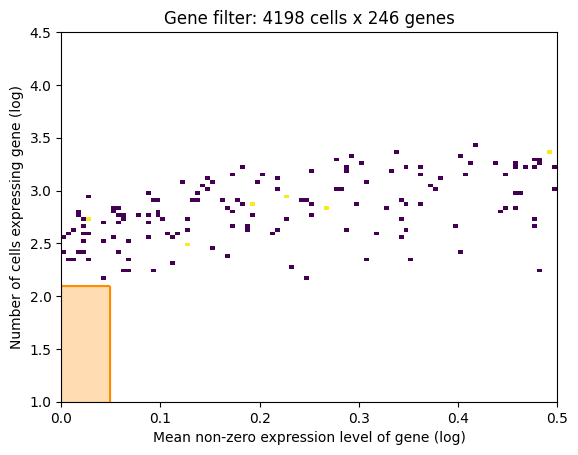

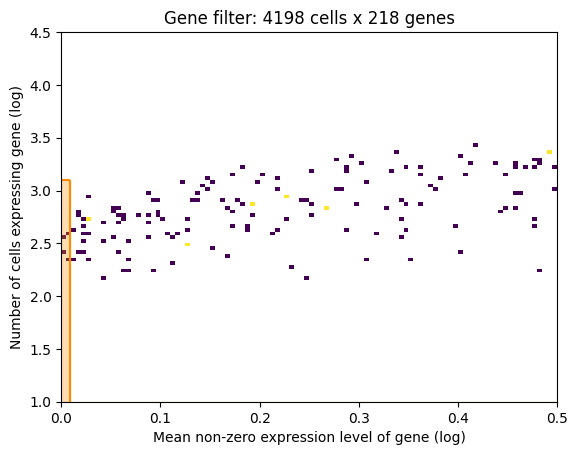

In [54]:
from cell2location.utils.filtering import filter_genes
selected = filter_genes(adata_ref, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)

selected = filter_genes(adata_ref, cell_count_cutoff=3, cell_percentage_cutoff2=0.3, nonz_mean_cutoff=1.02)


adata_ref.obs['Sample']='S1'
adata_ref.obs['Method']='M'
# filter the object
adata_ref = adata_ref[:, selected].copy()

In [57]:
adata_ref.obs

,x_coord,y_coord,slice_id,celltype,Sample,Method,_indices,_scvi_batch
cell_id,,,,,,,,
100047181052654346224529175853339022386,4280.917239,-3055.375620,mouse1_slice50,Oligo,S1,M,0,0
100144987682981782100923292757524648699,3832.852892,-3637.815477,mouse1_slice50,VLMC,S1,M,1,0
100267747580756240041023704492842942950,5048.352454,-2615.303647,mouse1_slice50,Astro,S1,M,2,0
100380418078413692631351412383892166094,4319.829363,-3040.423460,mouse1_slice50,L4/5 IT,S1,M,3,0
100416591302420540942373170232872783233,4214.585467,-3425.972085,mouse1_slice50,L4/5 IT,S1,M,4,0
...,...,...,...,...,...,...,...,...
99504125950471062201252312391570289780,4471.044126,-2178.374794,mouse1_slice50,L2/3 IT,S1,M,4193,0
99576957710400794105941222351708881383,4513.814201,-3748.785131,mouse1_slice50,L5 IT,S1,M,4194,0
99702068459277783182220371956699162352,4822.186113,-3754.969910,mouse1_slice50,L5 ET,S1,M,4195,0


In [58]:
# prepare anndata for the regression model
cell2location.models.RegressionModel.setup_anndata(adata=adata_ref,
                        # 10X reaction / sample / batch
                        batch_key='Sample',
                        # cell type, covariate used for constructing signatures
                        labels_key='celltype',
                        # multiplicative technical effects (platform, 3' vs 5', donor effect)
                        categorical_covariate_keys=['Method']
                       )

/home/qyyuan/anaconda3/envs/cell2loc_env/lib/python3.10/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [64]:
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.3.3.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'Sample',
│   'labels_key': 'celltype',
│   'categorical_covariate_keys': ['Method'],
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 4198  │
│ n_extra_categorical_covs │   1   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  23   │
│          n_vars          │  218  │
└──────────────────────────┴───────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │                  adata.X                   │
│         batch          │          adata.obs['_scvi_batch']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
│         ind_x          │           adata.obs['_indices']            │
│         labels         │         adata.obs['_scvi_labels']          │
└────────────────────────┴────────────────────────────────────────────┘

                   batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Sample'] │     S1     │          0          │
└─────────────────────┴────────────┴─────────────────────┘

                   labels State Registry                    
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location    ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['celltype'] │   Astro    │          0          │
│                       │    Endo    │          1          │
│                       │  L2/3 IT   │          2          │
│                       │  L4/5 IT   │          3          │
│                       │   L5 ET    │          4          │
│                       │   L5 IT    │          5          │
│                       │  L5/6 NP   │          6          │
│                       │   L6 CT    │          7          │
│                       │   L6 IT    │          8          │
│                       │ L6 IT Car3 │          9          │
│                       │    L6b     │         10          │
│                       │   Lamp5    │         11          │
│                       │   Micro    │         12          │
│                       │    OPC     │         13          │
│                       │   Oligo    │         14          │
│                       │    PVM     │         15          │
│                       │    Peri    │         16          │
│                       │   Pvalb    │         17          │
│                       │    SMC     │         18          │
│                       │    Sncg    │         19          │
│                       │    Sst     │         20          │
│                       │    VLMC    │         21          │
│                       │    Vip     │         22          │
└───────────────────────┴────────────┴─────────────────────┘

          extra_categorical_covs State Registry           
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Method'] │     M      │          0          │
│                     │            │                     │
└─────────────────────┴────────────┴─────────────────────┘

In [65]:
# create the regression model
from cell2location.models import RegressionModel
mod = RegressionModel(adata_ref)

# view anndata_setup as a sanity check
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.3.3.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'Sample',
│   'labels_key': 'celltype',
│   'categorical_covariate_keys': ['Method'],
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 4198  │
│ n_extra_categorical_covs │   1   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │  23   │
│          n_vars          │  218  │
└──────────────────────────┴───────┘

                             Data Registry                             
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Registry Key      ┃            scvi-tools Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X            │                  adata.X                   │
│         batch          │          adata.obs['_scvi_batch']          │
│ extra_categorical_covs │ adata.obsm['_scvi_extra_categorical_covs'] │
│         ind_x          │           adata.obs['_indices']            │
│         labels         │         adata.obs['_scvi_labels']          │
└────────────────────────┴────────────────────────────────────────────┘

                   batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Sample'] │     S1     │          0          │
└─────────────────────┴────────────┴─────────────────────┘

                   labels State Registry                    
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location    ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['celltype'] │   Astro    │          0          │
│                       │    Endo    │          1          │
│                       │  L2/3 IT   │          2          │
│                       │  L4/5 IT   │          3          │
│                       │   L5 ET    │          4          │
│                       │   L5 IT    │          5          │
│                       │  L5/6 NP   │          6          │
│                       │   L6 CT    │          7          │
│                       │   L6 IT    │          8          │
│                       │ L6 IT Car3 │          9          │
│                       │    L6b     │         10          │
│                       │   Lamp5    │         11          │
│                       │   Micro    │         12          │
│                       │    OPC     │         13          │
│                       │   Oligo    │         14          │
│                       │    PVM     │         15          │
│                       │    Peri    │         16          │
│                       │   Pvalb    │         17          │
│                       │    SMC     │         18          │
│                       │    Sncg    │         19          │
│                       │    Sst     │         20          │
│                       │    VLMC    │         21          │
│                       │    Vip     │         22          │
└───────────────────────┴────────────┴─────────────────────┘

          extra_categorical_covs State Registry           
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Method'] │     M      │          0          │
│                     │            │                     │
└─────────────────────┴────────────┴─────────────────────┘

In [63]:
import sys
import rich
import importlib.metadata as md

print("Python:", sys.executable)
print("rich path:", getattr(rich, "__file__", None))
print("rich version:", md.version("rich"))
print("scvi-tools version:", md.version("scvi-tools"))
print("cell2location version:", md.version("cell2location"))

try:
    import rich.pretty
    print("rich.pretty import: OK")
except Exception as e:
    print("rich.pretty import failed:", repr(e))

Python: /home/qyyuan/anaconda3/envs/cell2loc_env/bin/python
rich path: /home/qyyuan/anaconda3/envs/cell2loc_env/lib/python3.10/site-packages/rich/__init__.py
rich version: 15.0.0
scvi-tools version: 1.3.3
cell2location version: 0.1.5
rich.pretty import: OK


In [60]:
!pip install -U rich

### Question: cell2location need intpu count to be intger.

In [66]:
mod.train(max_epochs=250)

Trainer will use only 1 of 6 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=6)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/qyyuan/anaconda3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off pre

Training:   0%|          | 0/250 [00:00<?, ?it/s]

ValueError: Error while computing log_prob at site 'data_target':
Expected value argument (Tensor of shape (2500, 218)) to be within the support (IntegerGreaterThan(lower_bound=0)) of the distribution GammaPoisson(), but found invalid values:
tensor([[0.0000, 0.0000, 0.0000,  ..., 1.3226, 0.0367, 0.0829],
        [0.7567, 1.5134, 0.0000,  ..., 0.1498, 0.0673, 0.0000],
        [1.9243, 1.9243, 0.0000,  ..., 6.3020, 0.1088, 0.0079],
        ...,
        [3.4468, 0.0000, 0.0000,  ..., 1.0943, 0.0525, 0.3839],
        [0.0000, 0.0000, 0.0000,  ..., 0.3065, 0.0421, 0.7769],
        [0.0000, 0.0000, 0.0000,  ..., 4.2476, 0.1748, 0.0000]],
       device='cuda:0')
                Trace Shapes:                  
                 Param Sites:                  
                Sample Sites:                  
       per_cluster_mu_fg dist          | 23 218
                        value          | 23 218
                     log_prob          |       
  detection_tech_gene_tg dist          |  1 218

In [33]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
adata_ref = mod.export_posterior(
    adata_ref, sample_kwargs={'num_samples': 1000, 'batch_size': 2500,}
)

# Save model
mod.save(f"{ref_run_name}", overwrite=True)

# Save anndata object with results
adata_file = f"{ref_run_name}/sc.h5ad"
adata_ref.write(adata_file)
adata_file

Trainer will use only 1 of 6 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=6)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


Sampling local variables, batch:   0%|          | 0/8 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

'./cell2location_results//reference_signatures/sc.h5ad'

In [36]:
# export estimated expression in each cluster
if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
    inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
else:
    inf_aver = adata_ref.var[[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
inf_aver.columns = adata_ref.uns['mod']['factor_names']
inf_aver.iloc[0:5, 0:5]

,Astro,BCell,CA,DG,Endo
Xkr4,0.117350,0.025204,6.313676,2.950388,0.096283
Gm1992,0.000816,0.006321,0.234387,0.126540,0.005326
Sox17,0.004783,0.006684,0.002158,0.001880,1.618238
Mrpl15,0.129906,0.066278,0.286142,0.135904,0.147805
Lypla1,0.329686,0.095675,0.001965,0.001790,0.006694


In [38]:
# find shared genes and subset both anndata and reference signatures
intersect = np.intersect1d(adata_vis.var_names, inf_aver.index)
adata_vis = adata_vis[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()

# prepare anndata for cell2location model
cell2location.models.Cell2location.setup_anndata(adata=adata_vis, batch_key="sample")

/home/qyyuan/anaconda3/envs/cell2loc_env/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [39]:
# create and train the model
mod = cell2location.models.Cell2location(
    adata_vis, cell_state_df=inf_aver,
    # the expected average cell abundance: tissue-dependent
    # hyper-prior which can be estimated from paired histology:
    N_cells_per_location=30,
    # hyperparameter controlling normalisation of
    # within-experiment variation in RNA detection:
    detection_alpha=20
)


Anndata setup with scvi-tools version 1.3.3.

Setup via `Cell2location.setup_anndata` with arguments:

AttributeError: module 'rich' has no attribute 'pretty'

Trainer will use only 1 of 6 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=6)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
Trainer will use only 1 of 6 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=6)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/qyyuan/anaconda3/envs/cell2loc_env/lib/python3.10/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You

Training:   0%|          | 0/30000 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30000` reached.


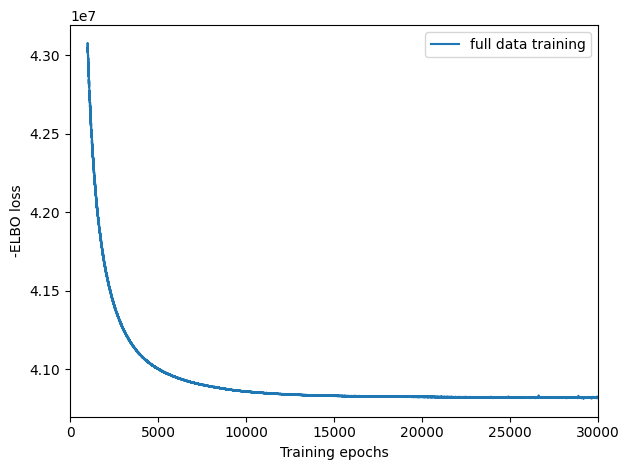

In [41]:
mod.train(max_epochs=30000,
          # train using full data (batch_size=None)
          batch_size=None,
          # use all data points in training because
          # we need to estimate cell abundance at all locations
          train_size=1
         )

# plot ELBO loss history during training, removing first 100 epochs from the plot
mod.plot_history(1000)
plt.legend(labels=['full data training']);

In [43]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
adata_vis = mod.export_posterior(
    adata_vis, sample_kwargs={'num_samples': 1000, 'batch_size': mod.adata.n_obs}
)

# Save model
mod.save(f"{run_name}", overwrite=True)

# mod = cell2location.models.Cell2location.load(f"{run_name}", adata_vis)

# Save anndata object with results
adata_file = f"{run_name}/sp.h5ad"
adata_vis.write(adata_file)
adata_file

Trainer will use only 1 of 6 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=6)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


Sampling local variables, batch:   0%|          | 0/1 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

'./cell2location_results//cell2location_map/sp.h5ad'

In [ ]:
adata_vis.obsm['q05_cell_abundance_w_sf'].to_csv('/home/qyyuan/project/ST_CP/JE/NC_review/Methods/Benchmark/jiyuanYang/deconvolution/cell2location_results/q05_cell_abundance_w_sf.csv')

In [53]:
!pip3 install igraph
!pip3 install leidenalg

  Using cached leidenalg-0.12.0-cp38-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (10 kB)
Using cached leidenalg-0.12.0-cp38-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (2.7 MB)


In [50]:
# compute KNN using the cell2location output stored in adata.obsm
sc.pp.neighbors(adata_vis, use_rep='q05_cell_abundance_w_sf',
                n_neighbors = 15)



ImportError: Please install the igraph package: `conda install -c conda-forge python-igraph` or `pip3 install igraph`.

In [54]:
# Cluster spots into regions using scanpy
sc.tl.leiden(adata_vis, resolution=1.1)

# add region as categorical variable
adata_vis.obs["region_cluster"] = adata_vis.obs["leiden"].astype("category")

/tmp/ipykernel_1467871/3881149293.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_vis, resolution=1.1)


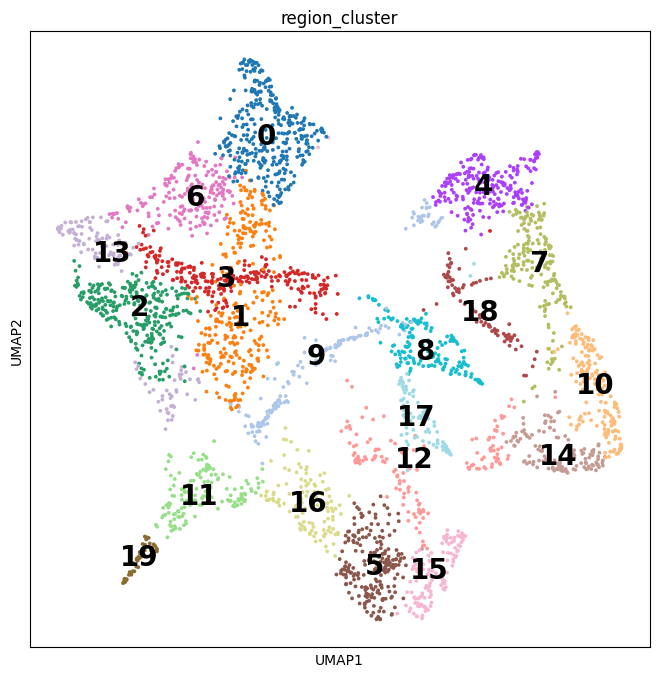

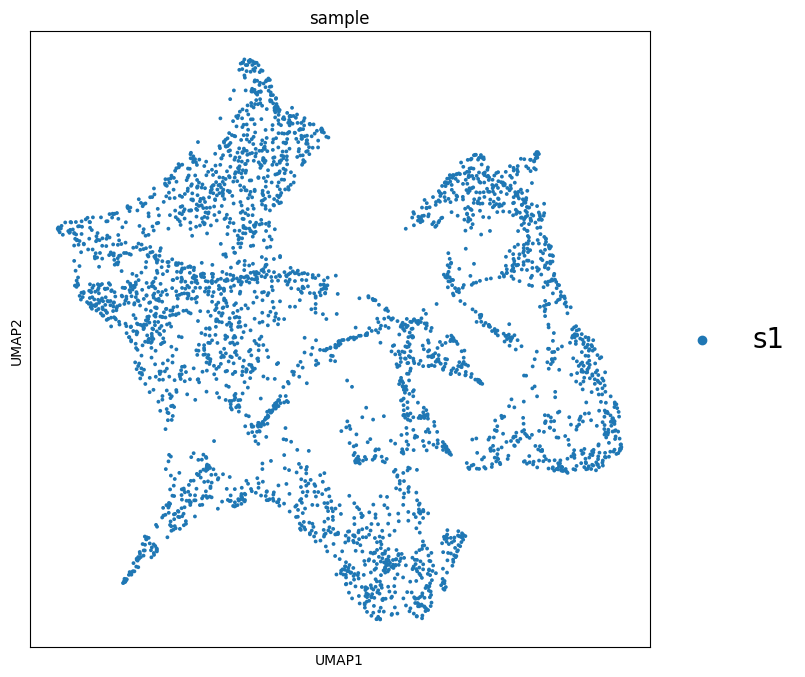

/tmp/ipykernel_1467871/3691370081.py:17: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_vis, color=['region_cluster'],


ValueError: When .uns['spatial'][library_id] does not exist, spot_size must be provided directly.

In [55]:
# compute UMAP using KNN graph based on the cell2location output
sc.tl.umap(adata_vis, min_dist = 0.3, spread = 1)

# show regions in UMAP coordinates
with mpl.rc_context({'axes.facecolor':  'white',
                     'figure.figsize': [8, 8]}):
    sc.pl.umap(adata_vis, color=['region_cluster'], size=30,
               color_map = 'RdPu', ncols = 2, legend_loc='on data',
               legend_fontsize=20)
    sc.pl.umap(adata_vis, color=['sample'], size=30,
               color_map = 'RdPu', ncols = 2,
               legend_fontsize=20)

# plot in spatial coordinates
with mpl.rc_context({'axes.facecolor':  'black',
                     'figure.figsize': [4.5, 5]}):
    sc.pl.spatial(adata_vis, color=['region_cluster'],
                  size=1.3, img_key='hires', alpha=0.5)

In [56]:
from cell2location import run_colocation
res_dict, adata_vis = run_colocation(
    adata_vis,
    model_name='CoLocatedGroupsSklearnNMF',
    train_args={
      'n_fact': np.arange(11, 13), # IMPORTANT: use a wider range of the number of factors (5-30)
      'sample_name_col': 'sample', # columns in adata_vis.obs that identifies sample
      'n_restarts': 3 # number of training restarts
    },
    # the hyperparameters of NMF can be also adjusted:
    model_kwargs={'alpha': 0.01, 'init': 'random', "nmf_kwd_args": {"tol": 0.000001}},
    export_args={'path': f'{run_name}/CoLocatedComb/'}
)

### Analysis name: CoLocatedGroupsSklearnNMF_11combinations_3476locations_27factors
Some error in plotting with scanpy or `cell2location.plt.plot_factor_spatial()`
 No module named 'plotnine'
### Analysis name: CoLocatedGroupsSklearnNMF_12combinations_3476locations_27factors
Some error in plotting with scanpy or `cell2location.plt.plot_factor_spatial()`
 No module named 'plotnine'
